# A new task?

Well I was looking in kaggle for some free dataset to work on and then, I found this challnge ... Let's get in it!

# What is the dataset and What is our target?

We have [titanic dataset](https://www.kaggle.com/competitions/titanic) And our task is  to use machine learning to predict which passengers survived the sinking of the RMS Titanic. So our task is binary classification.

We are provided with two CSV datasets:
* **train.csv**: Contains details for 891 passengers, including the "ground truth" (whether they survived or not). You use this data to build your model.
* **test.csv**: Contains data for 418 passengers without the survival outcome. Your task is to predict survival for these passengers.

We have also these features:
- **1. PassengerId**  
    - **Type**: Integer  
    - **Description**: A unique identifier for each passenger (row number).  
    - **Note**: Used only to identify submissions; no predictive value.

- **2. Survived**  
    - **Type**: Binary integer (0 = No, 1 = Yes)  
    - **Description**: Whether the passenger survived the disaster.  
    - **Note**: This is the **target variable** in `train.csv`. It is **absent** from `test.csv` (you must predict it).

- **3. Pclass**  
    - **Type**: Categorical integer (1, 2, 3)  
    - **Description**: Ticket class → 1st (upper), 2nd (middle), 3rd (lower).  
    - **Insight**: Strong predictor of survival (1st class had better access to lifeboats).

- **4. Name**  
    - **Type**: String  
    - **Description**: Passenger’s full name (including titles like Mr., Mrs., Master, etc.).  
    - **Insight**: Titles (e.g., “Miss” vs. “Mr.”) can hint at gender, age, or social status.

- **5. Sex**  
    - **Type**: String (male / female)  
    - **Description**: Gender of the passenger.  
    - **Insight**: One of the strongest predictors – “women and children first” policy meant far higher survival for females.

- **6. Age**  
    - **Type**: Float (years)  
    - **Description**: Age at the time of travel.  
    - **Note**: Contains **missing values** (≈20% in `train.csv`).  
    - **Insight**: Children (especially under 10) had higher survival rates.

- **7. SibSp**  
    - **Type**: Integer  
    - **Description**: Number of **siblings** (brother/sister) or **spouse** aboard the Titanic.  
    - **Range**: 0–8.  
    - **Insight**: Small families (1–3 members) often survived better; large families (≥4) had lower survival.

- **8. Parch**  
    - **Type**: Integer  
    - **Description**: Number of **parents** or **children** aboard.  
    - **Range**: 0–6.  
    - **Insight**: Similar to SibSp – helps define family size (often combined into `FamilySize = SibSp + Parch + 1`).

- **9. Ticket**  
    - **Type**: String (alphanumeric)  
    - **Description**: Ticket number (e.g., “A/5 21171”, “PC 17599”).  
    - **Insight**: Can reveal traveling groups (same ticket number = shared cabin or group booking) and sometimes ticket class.

- **10. Fare**  
    - **Type**: Float  
    - **Description**: Ticket price (in British pounds).  
    - **Note**: Few missing values.  
    - **Insight**: Higher fare generally correlates with higher Pclass and better survival odds.

- **11. Cabin**  
    - **Type**: String (e.g., “C85”, “B18”)  
    - **Description**: Cabin number.  
    - **Note**: **Heavily missing** (≈77% empty in `train.csv`).  
    - **Insight**: First letter indicates deck (A–G). Non‑null values often imply higher class / better survival.

- **12. Embarked**  
    - **Type**: String (C = Cherbourg, Q = Queenstown, S = Southampton)  
    - **Description**: Port where passenger boarded.  
    - **Note**: Two missing values in `train.csv`.  
    - **Insight**: Cherbourg passengers had higher survival rate (likely because more first‑class passengers boarded there).

# Evaluation metric

For this challnge our evaluation metric is accuracy.

# Code Part

## Import needed libraries

In [283]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler, StandardScaler

import helpers

SEED = 7968

## Data Part

Before we begin, the `test.csv` target feature is inside of `gender_submission.csv` file, so let's merge them together:

In [284]:
df_test_x = pd.read_csv("./test.csv")
df_test_y = pd.read_csv("./gender_submission.csv")

df_test = pd.merge(df_test_x, df_test_y, on="PassengerId")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


Now I want to concat all test and train data together:

In [285]:
df_train = pd.read_csv("./train.csv")

df = pd.concat([df_test, df_train])
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     1309 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 132.9+ KB


Uh oh, somthing smells bad ... Let's check null fields:

In [287]:
missing_values_percentage = (df.isna().sum() / df.PassengerId.count()) * 100
missing_values_percentage

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
Survived        0.000000
dtype: float64

Ok as we can see 77 percentage of feature `cabin` is missing. 20 percentage of feature `Age` is missing too with some other features.

### How many people survived and howmany didn't?

<Axes: >

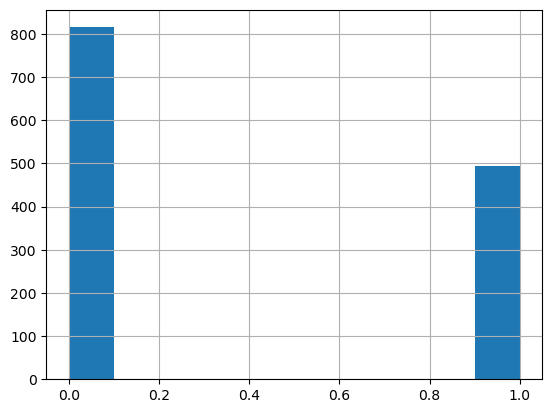

In [288]:
df["Survived"].hist()

Ohh, this is not good.

### How many male and female survived and how many did not

In [289]:
print("Survived\n")
print(df[df["Survived"] == 1].groupby("Sex")["Survived"].count())

Survived

Sex
female    385
male      109
Name: Survived, dtype: int64


In [290]:
print("Did not survived\n")
print(df[df["Survived"] == 0].groupby("Sex")["Survived"].count())

Did not survived

Sex
female     81
male      734
Name: Survived, dtype: int64


In [291]:
print(
    "People with ticket class 1 survive count:",
    df[(df["Pclass"] == 1) & (df["Survived"] == 1)]["Survived"].sum(),
)
print(
    "People with ticket class 2 survive count:",
    df[(df["Pclass"] == 2) & (df["Survived"] == 1)]["Survived"].sum(),
)
print(
    "People with ticket class 3 survive count:",
    df[(df["Pclass"] == 3) & (df["Survived"] == 1)]["Survived"].sum(),
)

People with ticket class 1 survive count: 186
People with ticket class 2 survive count: 117
People with ticket class 3 survive count: 191


Let's analyze numerical features more

<Axes: >

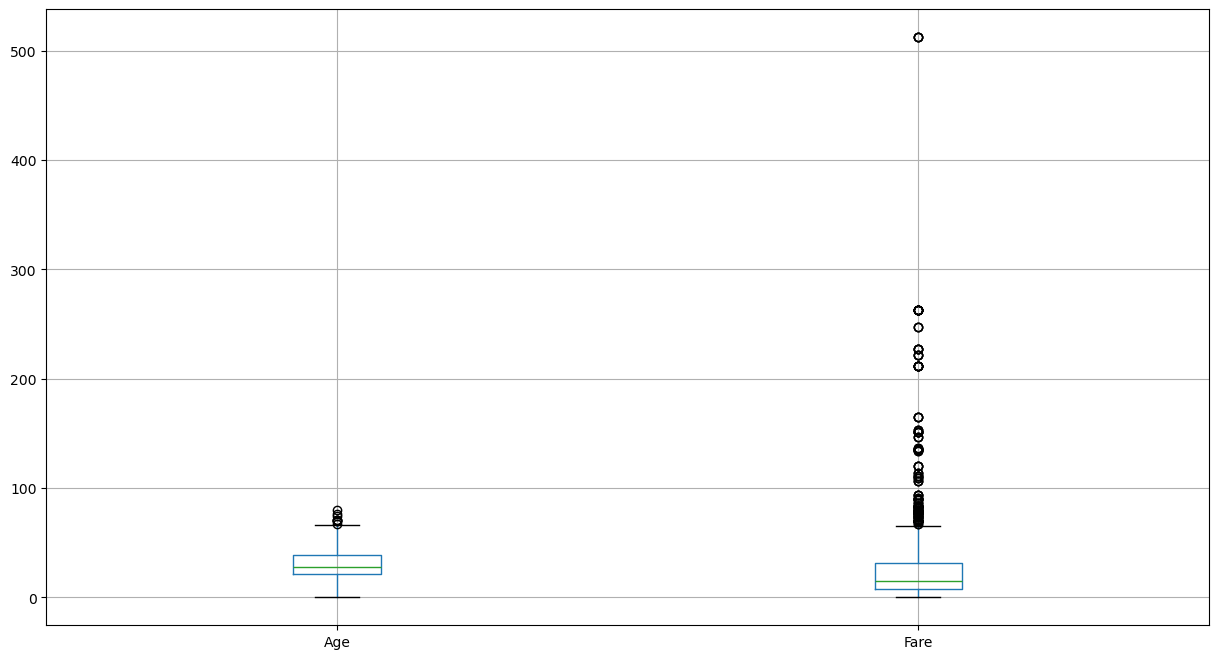

In [292]:
df_num = df.select_dtypes("float64")
df_num.boxplot(figsize=(15, 8))

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

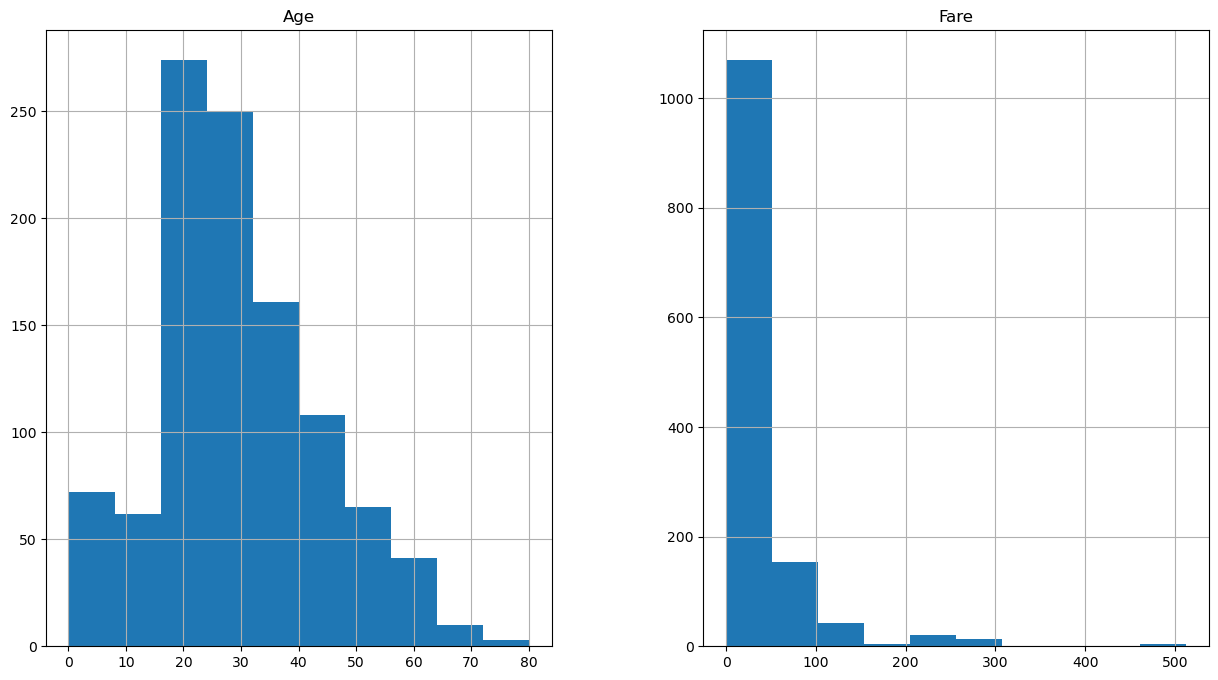

In [293]:
df_num.hist(figsize=(15, 8))

In [294]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1046.0,29.881138,14.413493,0.17,21.0000,28.0000,39.000,80.0000
Fare,1308.0,33.295479,51.758668,0.00,7.8958,14.4542,31.275,512.3292


I can use **robust scalar** for feature `Fare` but, I may just use IQR approch.

## Preprocess + Feature Engineering

I'll analyze so many things but first I need to handel some problems.

### Drop useless features

In [295]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

I don't need `PassengerId` and `Name`.

### Convert feature `Sex` and `Embarked` to number

In [296]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

### Handel missing values

In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Sex       1309 non-null   int64  
 2   Age       1046 non-null   float64
 3   SibSp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Fare      1308 non-null   float64
 6   Cabin     295 non-null    object 
 7   Embarked  1309 non-null   int64  
 8   Survived  1309 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 102.3+ KB


features `Fare` and `Embarked` don't have a lot of missig values, so I'll fill them using **mode** and **mean**.

In [298]:
df["Fare"] = df["Fare"].fillna(value=df["Fare"].mean())
df["Embarked"] = df["Embarked"].fillna(value=df["Embarked"].mode())

Feature `Cabin` has a lot of missing values, I want to remove it and create another feature named `missing_cabin` for saving a feature.

In [ ]:
df["Missing_cabin"] = df["Cabin"].isna().astype("int")
df = df.drop(columns=["Cabin"])
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,34.5,0,0,7.8292,1,0
1,3,0,47.0,1,0,7.0000,2,1
2,2,1,62.0,0,0,9.6875,1,0
3,3,1,27.0,0,0,8.6625,2,0
4,3,0,22.0,1,1,12.2875,2,1


For feature `Age` I'll use **KNN Imputer**. So i need to first train and test split data

In [300]:
X = df.drop(columns=["Survived"])
y = df.Survived
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

I also want to scale feature `Fare`

In [301]:
rb = RobustScaler()
X_train = rb.fit_transform(X_train, y_train)
X_test = rb.transform(X_test)

In [302]:
knn = KNNImputer()
X_train = knn.fit_transform(X_train, y_train)
X_test = knn.transform(X_test)

## Model

### Logistic Regression

In [325]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [326]:
y_pred = lr.predict(X_test)
helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression"
)

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       167
           1       0.88      0.81      0.84        95

    accuracy                           0.89       262
   macro avg       0.89      0.87      0.88       262
weighted avg       0.89      0.89      0.89       262



In [305]:
lr_grid = LogisticRegression()

param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    "max_iter": [200, 300, 400]
}

lr_grid = helpers.run_grid_search(
    model=lr_grid,
    param_grid=param_grid_lr,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="LogisticRegression with gridsearch"
)

Fitting 3 folds for each of 36 candidates, totalling 108 fits



--- Grid Search for `LogisticRegression with gridsearch` ---
Best Hyper Parameters: {'C': 1, 'max_iter': 300, 'penalty': 'l1', 'solver': 'liblinear'}
Best Mean Log Loss (CV): 0.3944


In [306]:
y_pred = lr_grid.predict(X_test)
helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression"
)

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       167
           1       0.88      0.81      0.84        95

    accuracy                           0.89       262
   macro avg       0.89      0.87      0.88       262
weighted avg       0.89      0.89      0.89       262



### SVM

In [335]:

svc = SVC(random_state=SEED, probability=True)
svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [336]:
y_pred = svc.predict(X_test)
helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression"
)

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       167
           1       0.86      0.82      0.84        95

    accuracy                           0.89       262
   macro avg       0.88      0.87      0.87       262
weighted avg       0.88      0.89      0.88       262



In [309]:
svc_grid = SVC(random_state=SEED, probability=True)

param_grid_svc = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"],
}

svc_grid = helpers.run_grid_search(
    model=svc_grid,
    param_grid=param_grid_svc,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="SVC with gridsearch"
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits



--- Grid Search for `SVC with gridsearch` ---
Best Hyper Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Mean Log Loss (CV): 0.3919


In [310]:
y_pred = svc_grid.predict(X_test)
helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression"
)

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       167
           1       0.86      0.83      0.84        95

    accuracy                           0.89       262
   macro avg       0.88      0.88      0.88       262
weighted avg       0.89      0.89      0.89       262



### Enesemble

In [337]:
rfc = RandomForestClassifier(random_state=SEED)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [338]:
y_pred = rfc.predict(X_test)
helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression"
)

              precision    recall  f1-score   support

           0       0.91      0.86      0.89       167
           1       0.78      0.85      0.81        95

    accuracy                           0.86       262
   macro avg       0.85      0.86      0.85       262
weighted avg       0.86      0.86      0.86       262



In [314]:
rfc_grid = RandomForestClassifier(random_state=SEED)

param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_grid = helpers.run_grid_search(
    model=rfc_grid,
    param_grid=param_grid_rf,
    X=X_train,
    y=y_train,
    cv=3,
    model_name="RandomForestClassifier with gridsearch"
)

Fitting 3 folds for each of 162 candidates, totalling 486 fits



--- Grid Search for `RandomForestClassifier with gridsearch` ---
Best Hyper Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Mean Log Loss (CV): 0.3754


In [315]:
y_pred = rfc_grid.predict(X_test)
helpers.evaluate_classification_model(
    y_test=y_test, y_pred=y_pred, model_name="LogisticRegression"
)

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       167
           1       0.83      0.84      0.84        95

    accuracy                           0.88       262
   macro avg       0.87      0.87      0.87       262
weighted avg       0.88      0.88      0.88       262

